In [ ]:
from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset

import pandas as pd
import numpy as np

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

ds = load_dataset(
    "electricsheepafrica/Nigerian-Financial-Transactions-and-Fraud-Detection-Dataset",
    split="train[:100000]"
)

df = ds.to_pandas()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])

# Remove known leakage / unused columns
df.drop(columns=[
    "fraud_type",
    "time_since_last_transaction"
], inplace=True, errors='ignore')

In [ ]:
df['txn_hour'] = df['timestamp'].dt.hour
df['txn_day'] = df['timestamp'].dt.dayofweek
df['txn_month'] = df['timestamp'].dt.month

df['is_night_txn'] = df['txn_hour'].apply(lambda x: 1 if x >= 22 or x <= 5 else 0)
df['is_weekend'] = df['txn_day'].apply(lambda x: 1 if x >= 5 else 0)

df.drop(columns=['timestamp'], inplace=True)

In [ ]:
target = "is_fraud"
X = df.drop(columns=[target])
y = df[target]

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
models = {
    "log_reg": LogisticRegression(max_iter=1000, class_weight="balanced"),

    "random_forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "xgboost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        eval_metric="logloss"
    ),

    "lightgbm": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced"
    )
}

/tmp/ipykernel_787/4217742611.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),


In [ ]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

In [ ]:
results = {}
trained_models = {}

for name, model in models.items():

    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    preds_proba = clf.predict_proba(X_test)[:, 1]
    preds = (preds_proba > 0.5).astype(int)

    results[name] = {
        "roc_auc": roc_auc_score(y_test, preds_proba),
        "recall": recall_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "f1": f1_score(y_test, preds)
    }

    trained_models[name] = clf

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[LightGBM] [Info] Number of positive: 2898, number of negative: 77102
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009007 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3344
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 98
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).T

best_model_name = results_df.sort_values(
    by=["roc_auc", "recall"],
    ascending=False
).index[0]

best_model = trained_models[best_model_name]

print("BEST MODEL:", best_model_name)
print(results_df)

BEST MODEL: xgboost
                roc_auc    recall  precision        f1
log_reg        0.520420  0.000000   0.000000  0.000000
random_forest  0.509815  0.000000   0.000000  0.000000
xgboost        0.522240  0.395862   0.038664  0.070447
lightgbm       0.518906  0.179310   0.036445  0.060578


In [ ]:
def predict_risk(model, X_input):

    probs = model.predict_proba(X_input)[:, 1]
    risk_score = probs * 100

    def category(x):
        if x < 30:
            return "LOW"
        elif x < 70:
            return "MEDIUM"
        else:
            return "HIGH"

    return pd.DataFrame({
        "fraud_probability": probs,
        "risk_score": risk_score,
        "risk_category": [category(x) for x in risk_score]
    })

In [ ]:
def predict_transaction(model, input_df):

    input_df = input_df.copy()

    # feature engineering must match training
    input_df['txn_hour'] = input_df['timestamp'].dt.hour
    input_df['txn_day'] = input_df['timestamp'].dt.dayofweek
    input_df['is_night_txn'] = input_df['txn_hour'].apply(lambda x: 1 if x >= 22 or x <= 5 else 0)
    input_df['is_weekend'] = input_df['txn_day'].apply(lambda x: 1 if x >= 5 else 0)

    input_df = input_df.drop(columns=["timestamp"], errors="ignore")

    probs = model.predict_proba(input_df)[:, 1]
    risk = probs * 100

    return pd.DataFrame({
        "predicted_is_fraud": (probs > 0.5).astype(int),
        "fraud_probability": probs,
        "risk_score": risk,
        "risk_category": ["LOW" if r < 30 else "MEDIUM" if r < 70 else "HIGH" for r in risk]
    })

In [ ]:
import joblib

joblib.dump(best_model, "fraud_detection_model.pkl")
print("Model saved successfully")

Model saved successfully


In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="roc_auc", ascending=False)

print("\n===== MODEL COMPARISON RESULTS =====\n")
print(results_df)


===== MODEL COMPARISON RESULTS =====

                roc_auc    recall  precision        f1
xgboost        0.522240  0.395862   0.038664  0.070447
log_reg        0.520420  0.000000   0.000000  0.000000
lightgbm       0.518906  0.179310   0.036445  0.060578
random_forest  0.509815  0.000000   0.000000  0.000000


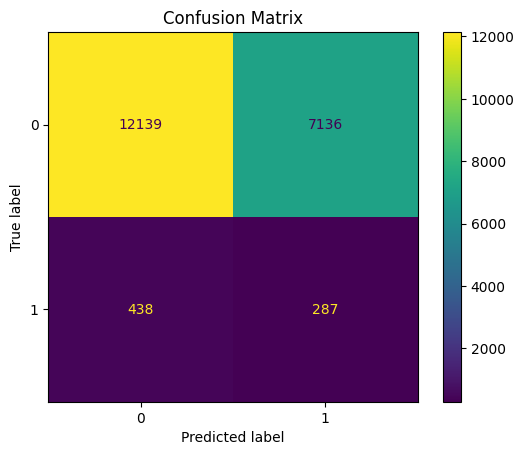

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = (best_model.predict_proba(X_test)[:, 1] > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [74]:
from google.colab import files

files.download("fraud_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>